In [1]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 4060 Laptop GPU


In [2]:
import numpy as np
from PIL import Image
from PIL import ImageFilter
import torch
from torch.utils.data import Dataset
from torchvision.transforms import functional as TF
from torchvision.transforms import InterpolationMode

In [3]:
DATA_DIR = "../data"

In [4]:
import os, glob, re
from dataclasses import dataclass

TUMOR_TO_ID = {"nt": 0, "gl": 1, "me": 2, "pi": 3}
VIEW_TO_ID  = {"ax": 0, "co": 1, "sa": 2}

pat = re.compile(
    r"brisc2025_(?P<split>train|test)_(?P<idx>\d+)_(?P<tumor>gl|me|pi|nt)_(?P<view>ax|co|sa)_(?P<seq>t1)\.(?P<ext>jpg|png)$"
)

@dataclass(frozen=True)
class Sample:
    img_path: str
    mask_path: str | None
    tumor_id: int
    view_id: int
    split: str

def parse_name(fname: str):
    m = pat.match(os.path.basename(fname))
    if not m:
        return None
    d = m.groupdict()
    return d

def list_segmentation_pairs(root_images, root_masks):
    imgs = glob.glob(os.path.join(root_images, "**", "*.jpg"), recursive=True)
    samples = []
    for img_p in imgs:
        meta = parse_name(img_p)
        if not meta:
            continue
        base = os.path.splitext(os.path.basename(img_p))[0]
        mask_p = os.path.join(root_masks, base + ".png")

        if not os.path.exists(mask_p):
            candidates = glob.glob(os.path.join(root_masks, "**", base + ".png"), recursive=True)
            mask_p = candidates[0] if candidates else None
        samples.append((img_p, mask_p, meta))
    return samples

In [5]:
class BriscSegmentationDataset(Dataset):
    def __init__(self, pairs, size=256, augment=False):
        self.pairs = pairs
        self.size = size
        self.augment = augment

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, msk_path = self.pairs[idx]

        img = Image.open(img_path).convert("RGB")
        msk = Image.open(msk_path).convert("L")

        # Resize first
        img = img.resize((self.size, self.size), Image.BILINEAR)
        msk = msk.resize((self.size, self.size), Image.NEAREST)

        if self.augment:
            # -------- Geometric transforms: apply to both --------
            if random.random() < 0.5:
                img = TF.hflip(img)
                msk = TF.hflip(msk)

            if random.random() < 0.5:
                img = TF.vflip(img)
                msk = TF.vflip(msk)

            angle = random.uniform(-12, 12)
            img = TF.rotate(img, angle, interpolation=InterpolationMode.BILINEAR)
            msk = TF.rotate(msk, angle, interpolation=InterpolationMode.NEAREST)

            # mild affine
            if random.random() < 0.4:
                translate = (random.randint(-8, 8), random.randint(-8, 8))
                scale = random.uniform(0.95, 1.05)
                shear = random.uniform(-5, 5)
                img = TF.affine(
                    img, angle=0, translate=translate, scale=scale, shear=shear,
                    interpolation=InterpolationMode.BILINEAR
                )
                msk = TF.affine(
                    msk, angle=0, translate=translate, scale=scale, shear=shear,
                    interpolation=InterpolationMode.NEAREST
                )

            # -------- Image-only quality transforms --------
            if random.random() < 0.4:
                brightness_factor = random.uniform(0.85, 1.15)
                img = TF.adjust_brightness(img, brightness_factor)

            if random.random() < 0.4:
                contrast_factor = random.uniform(0.85, 1.20)
                img = TF.adjust_contrast(img, contrast_factor)

            if random.random() < 0.25:
                img = img.filter(ImageFilter.GaussianBlur(radius=random.uniform(0.2, 1.0)))

        # Convert to numpy
        img = np.array(img, dtype=np.float32) / 255.0
        msk = np.array(msk, dtype=np.uint8)

        # Add mild Gaussian noise after conversion
        if self.augment and random.random() < 0.25:
            noise = np.random.normal(0, 0.02, img.shape).astype(np.float32)
            img = np.clip(img + noise, 0.0, 1.0)

        img_t = torch.from_numpy(img).permute(2, 0, 1)  # (3,H,W)
        msk_t = torch.from_numpy((msk > 0).astype(np.float32)).unsqueeze(0)  # (1,H,W)

        return img_t, msk_t

In [6]:
ROOT = "C:\\Users\\user\\Desktop\\MedVision\\models\\data\\segmentation_task"

SEG_ROOT = os.path.join(ROOT, "segmentation_task")

SEG_IMG_ROOT  = os.path.join(SEG_ROOT, "images")
SEG_MASK_ROOT = os.path.join(SEG_ROOT, "binary masks") 

In [ ]:
import os, glob, random
from tqdm import tqdm

import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

In [8]:
ROOT = "../data/segmentation_task"

TRAIN_IMG = os.path.join(ROOT, "train", "images")
TRAIN_MSK = os.path.join(ROOT, "train", "masks")
TEST_IMG  = os.path.join(ROOT, "test",  "images")
TEST_MSK  = os.path.join(ROOT, "test",  "masks")

def list_pairs(img_dir, msk_dir):
    imgs = sorted(glob.glob(os.path.join(img_dir, "*.jpg")))
    pairs = []
    for ip in imgs:
        base = os.path.splitext(os.path.basename(ip))[0]
        mp = os.path.join(msk_dir, base + ".png")
        if os.path.exists(mp):
            pairs.append((ip, mp))
    return pairs

train_pairs = list_pairs(TRAIN_IMG, TRAIN_MSK)
test_pairs  = list_pairs(TEST_IMG,  TEST_MSK)

print("Train pairs:", len(train_pairs))
print("Test pairs:", len(test_pairs))
print("Example:", train_pairs[0] if train_pairs else None)

Train pairs: 3933
Test pairs: 860
Example: ('../data/segmentation_task\\train\\images\\brisc2025_train_00001_gl_ax_t1.jpg', '../data/segmentation_task\\train\\masks\\brisc2025_train_00001_gl_ax_t1.png')


In [9]:
class BriscSegDataset(Dataset):
    def __init__(self, pairs, size=256, augment=False):
        self.pairs = pairs
        self.size = size
        self.augment = augment

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, msk_path = self.pairs[idx]

        img = Image.open(img_path).convert("RGB")
        msk = Image.open(msk_path).convert("L")

        # Resize first
        img = img.resize((self.size, self.size), Image.BILINEAR)
        msk = msk.resize((self.size, self.size), Image.NEAREST)

        if self.augment:
            # -------- Geometric transforms: apply to both --------
            if random.random() < 0.5:
                img = TF.hflip(img)
                msk = TF.hflip(msk)

            if random.random() < 0.5:
                img = TF.vflip(img)
                msk = TF.vflip(msk)

            angle = random.uniform(-12, 12)
            img = TF.rotate(img, angle, interpolation=InterpolationMode.BILINEAR)
            msk = TF.rotate(msk, angle, interpolation=InterpolationMode.NEAREST)

            # mild affine
            if random.random() < 0.4:
                translate = (random.randint(-8, 8), random.randint(-8, 8))
                scale = random.uniform(0.95, 1.05)
                shear = random.uniform(-5, 5)
                img = TF.affine(
                    img, angle=0, translate=translate, scale=scale, shear=shear,
                    interpolation=InterpolationMode.BILINEAR
                )
                msk = TF.affine(
                    msk, angle=0, translate=translate, scale=scale, shear=shear,
                    interpolation=InterpolationMode.NEAREST
                )

            # -------- Image-only quality transforms --------
            if random.random() < 0.4:
                brightness_factor = random.uniform(0.85, 1.15)
                img = TF.adjust_brightness(img, brightness_factor)

            if random.random() < 0.4:
                contrast_factor = random.uniform(0.85, 1.20)
                img = TF.adjust_contrast(img, contrast_factor)

            if random.random() < 0.25:
                img = img.filter(ImageFilter.GaussianBlur(radius=random.uniform(0.2, 1.0)))

        # Convert to numpy
        img = np.array(img, dtype=np.float32) / 255.0
        msk = np.array(msk, dtype=np.uint8)

        # Add mild Gaussian noise after conversion
        if self.augment and random.random() < 0.25:
            noise = np.random.normal(0, 0.02, img.shape).astype(np.float32)
            img = np.clip(img + noise, 0.0, 1.0)

        img_t = torch.from_numpy(img).permute(2, 0, 1)  # (3,H,W)
        msk_t = torch.from_numpy((msk > 0).astype(np.float32)).unsqueeze(0)  # (1,H,W)

        return img_t, msk_t


In [10]:
train_ds = BriscSegDataset(train_pairs, size=256, augment=True)
test_ds  = BriscSegDataset(test_pairs,  size=256, augment=False)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=2, pin_memory=True )
test_loader  = DataLoader(test_ds,  batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

In [11]:
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd,
    ScaleIntensityd, Resized,
    RandRotate90d, RandFlipd, RandGaussianNoised
)

from monai.data import Dataset, DataLoader
from monai.networks.nets import UNet
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric
from monai.inferers import sliding_window_inference

c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
train_transforms = Compose([
    LoadImaged(keys=["image", "label"], image_only=True),
    EnsureChannelFirstd(keys=["image", "label"]),
    ScaleIntensityd(keys=["image"]),
    Resized(keys=["image", "label"], spatial_size=(256,256)),

    RandRotate90d(keys=["image", "label"], prob=0.5),
    RandFlipd(keys=["image", "label"], prob=0.5),
    RandGaussianNoised(keys=["image"], prob=0.2),
])

val_transforms = Compose([
    LoadImaged(keys=["image", "label"], image_only=True),
    EnsureChannelFirstd(keys=["image", "label"]),
    ScaleIntensityd(keys=["image"]),
    Resized(keys=["image", "label"], spatial_size=(256, 256)),
])

In [13]:
from sklearn.model_selection import train_test_split

SEED = 42
train_pairs_split, val_pairs = train_test_split(
    train_pairs, test_size=0.2, random_state=SEED, shuffle=True
)

print("Train split:", len(train_pairs_split))
print("Val split:", len(val_pairs))
print("Test:", len(test_pairs))

Train split: 3146
Val split: 787
Test: 860


In [14]:
train_ds = BriscSegDataset(train_pairs_split, size=256, augment=True)
val_ds   = BriscSegDataset(val_pairs,        size=256, augment=False)
test_ds  = BriscSegDataset(test_pairs,       size=256, augment=False)

# Safe settings for Windows + Jupyter to avoid DataLoader stalls.
train_loader = DataLoader(
    train_ds, batch_size=16, shuffle=True, num_workers=0,
    pin_memory=False, persistent_workers=False
)
val_loader = DataLoader(
    val_ds, batch_size=16, shuffle=False, num_workers=0,
    pin_memory=False, persistent_workers=False
)
test_loader = DataLoader(
    test_ds, batch_size=16, shuffle=False, num_workers=0,
    pin_memory=False, persistent_workers=False
)

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet(
    spatial_dims=2,
    in_channels=3,
    out_channels=1,
    channels=(32, 64, 128, 256),
    strides=(2, 2, 2),
    num_res_units=2,
    norm="INSTANCE",
    dropout=0.1,
).to(device)

In [ ]:
from monai.losses import DiceFocalLoss

# DiceFocalLoss is often stronger than DiceCE when masks are imbalanced.
loss_fn = DiceFocalLoss(sigmoid=True, lambda_dice=1.0, lambda_focal=1.0)

# AdamW + slightly higher LR is a strong baseline for UNet segmentation.
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-5)

# Scheduler monitors validation Dice (maximize).
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=True,
)


# AMP scaler is active only on CUDA.
scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))

dice_metric = DiceMetric(include_background=True, reduction="mean")
threshold_grid = [0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
C:\Users\user\AppData\Local\Temp\ipykernel_10332\2092604097.py:20: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))


In [17]:
# Sanity check without DataLoader iterator (cannot hang on worker startup)
img0, lbl0 = train_ds[0]
images = img0.unsqueeze(0).to(device)
labels = lbl0.unsqueeze(0).to(device)

with torch.no_grad():
    out = model(images)

print("Dataset type:", type(train_ds).__name__)
print("Loader num_workers:", train_loader.num_workers)
print("Single image shape:", images.shape)
print("Single label shape:", labels.shape)
print("Model output shape:", out.shape)

Dataset type: BriscSegDataset
Loader num_workers: 0
Single image shape: torch.Size([1, 3, 256, 256])
Single label shape: torch.Size([1, 1, 256, 256])
Model output shape: torch.Size([1, 1, 256, 256])


In [18]:
import copy
import time
from tqdm.auto import tqdm


def _dice_from_probs(probs, labels, threshold=0.5, eps=1e-6):
    preds = (probs > threshold).float()
    labels = labels.float()

    dims = (1, 2, 3)
    inter = (preds * labels).sum(dim=dims)
    denom = preds.sum(dim=dims) + labels.sum(dim=dims)
    dice = (2.0 * inter + eps) / (denom + eps)
    return dice.mean().item()


def evaluate_with_threshold_search(model, loader, threshold_grid):
    model.eval()
    best_dice = -1.0
    best_thr = 0.5

    # Collect probabilities and labels once; then sweep thresholds cheaply.
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=False)
            labels = labels.to(device, non_blocking=False)

            logits = model(images)
            probs = torch.sigmoid(logits)

            all_probs.append(probs)
            all_labels.append(labels)

    if not all_probs:
        return 0.0, 0.5

    all_probs = torch.cat(all_probs, dim=0)
    all_labels = torch.cat(all_labels, dim=0)

    for thr in threshold_grid:
        d = _dice_from_probs(all_probs, all_labels, threshold=thr)
        if d > best_dice:
            best_dice = d
            best_thr = thr

    return best_dice, best_thr


FULL_TRAINING = True
epochs = 40 if FULL_TRAINING else 3
debug_max_batches = None if FULL_TRAINING else 20
print_every = 20

best_val_dice = -1.0
best_threshold = 0.5
best_state = None
no_improve = 0
early_stop_patience = 8

print(f"Full training: {FULL_TRAINING} | epochs={epochs} | debug_max_batches={debug_max_batches}")

for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0
    start_t = time.time()

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
    for bidx, (images, labels) in enumerate(pbar, start=1):
        images = images.to(device, non_blocking=False)
        labels = labels.to(device, non_blocking=False)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            outputs = model(images)
            loss = loss_fn(outputs, labels)

        scaler.scale(loss).backward()

        # Stabilize training to protect Dice from occasional exploding steps.
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

        if bidx % print_every == 0:
            print(f"Epoch {epoch+1} - batch {bidx}/{len(train_loader)} - loss {loss.item():.4f}")

        if debug_max_batches is not None and bidx >= debug_max_batches:
            print(f"Debug stop at batch {bidx}")
            break

    steps = bidx if (debug_max_batches is not None and debug_max_batches < len(train_loader)) else len(train_loader)
    mean_loss = epoch_loss / max(steps, 1)

    val_dice, val_thr = evaluate_with_threshold_search(model, val_loader, threshold_grid)
    scheduler.step(val_dice)

    if val_dice > best_val_dice:
        best_val_dice = val_dice
        best_threshold = val_thr
        best_state = copy.deepcopy(model.state_dict())
        no_improve = 0
    else:
        no_improve += 1

    print(
        f"Epoch {epoch+1}/{epochs} | loss={mean_loss:.4f} | "
        f"val_dice={val_dice:.4f} | best_dice={best_val_dice:.4f} | "
        f"best_thr={best_threshold:.2f} | {time.time()-start_t:.1f}s"
    )

    if no_improve >= early_stop_patience:
        print(f"Early stopping at epoch {epoch+1} (no improvement for {early_stop_patience} epochs).")
        break

if best_state is not None:
    model.load_state_dict(best_state)

print(f"Loaded best model with val Dice={best_val_dice:.4f} at threshold={best_threshold:.2f}")

Full training: True | epochs=40 | debug_max_batches=None


Epoch 1/40:   0%|          | 0/197 [00:00<?, ?it/s]C:\Users\user\AppData\Local\Temp\ipykernel_10332\428288022.py:77: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
Epoch 1/40:  11%|█         | 21/197 [00:04<00:27,  6.35it/s, loss=1.2034]

Epoch 1 - batch 20/197 - loss 1.2210


Epoch 1/40:  21%|██        | 41/197 [00:07<00:25,  6.10it/s, loss=1.1949]

Epoch 1 - batch 40/197 - loss 1.1876


...

Epoch 40/40:  82%|████████▏ | 161/197 [00:25<00:06,  5.84it/s, loss=0.3166]

Epoch 40 - batch 160/197 - loss 0.2712


Epoch 40/40:  91%|█████████▏| 180/197 [00:28<00:02,  5.84it/s, loss=0.2551]

Epoch 40 - batch 180/197 - loss 0.1946


Epoch 40/40 | loss=0.2390 | val_dice=0.8148 | best_dice=0.8149 | best_thr=0.55 | 33.9s
Loaded best model with val Dice=0.8149 at threshold=0.55


In [19]:
from tqdm.auto import tqdm

model.eval()
dice_metric.reset()
debug_max_val_batches = None  # ex: 20

with torch.no_grad():
    pbar = tqdm(val_loader, desc="Validation", leave=False)
    for bidx, (images, labels) in enumerate(pbar, start=1):
        images = images.to(device, non_blocking=False)
        labels = labels.to(device, non_blocking=False)

        outputs = model(images)
        preds = torch.sigmoid(outputs) > best_threshold

        dice_metric(y_pred=preds, y=labels)

        if debug_max_val_batches is not None and bidx >= debug_max_val_batches:
            print(f"Validation debug stop at batch {bidx}")
            break

val_dice_final = dice_metric.aggregate().item()
print(f"Validation Dice with best threshold ({best_threshold:.2f}): {val_dice_final:.4f}")

# Optional: quick test-set estimate using the same threshold.
dice_metric.reset()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device, non_blocking=False)
        labels = labels.to(device, non_blocking=False)

        outputs = model(images)
        preds = torch.sigmoid(outputs) > best_threshold
        dice_metric(y_pred=preds, y=labels)

test_dice = dice_metric.aggregate().item()
print(f"Test Dice with tuned threshold: {test_dice:.4f}")

Validation Dice with best threshold (0.55): 0.8149
Test Dice with tuned threshold: 0.8154


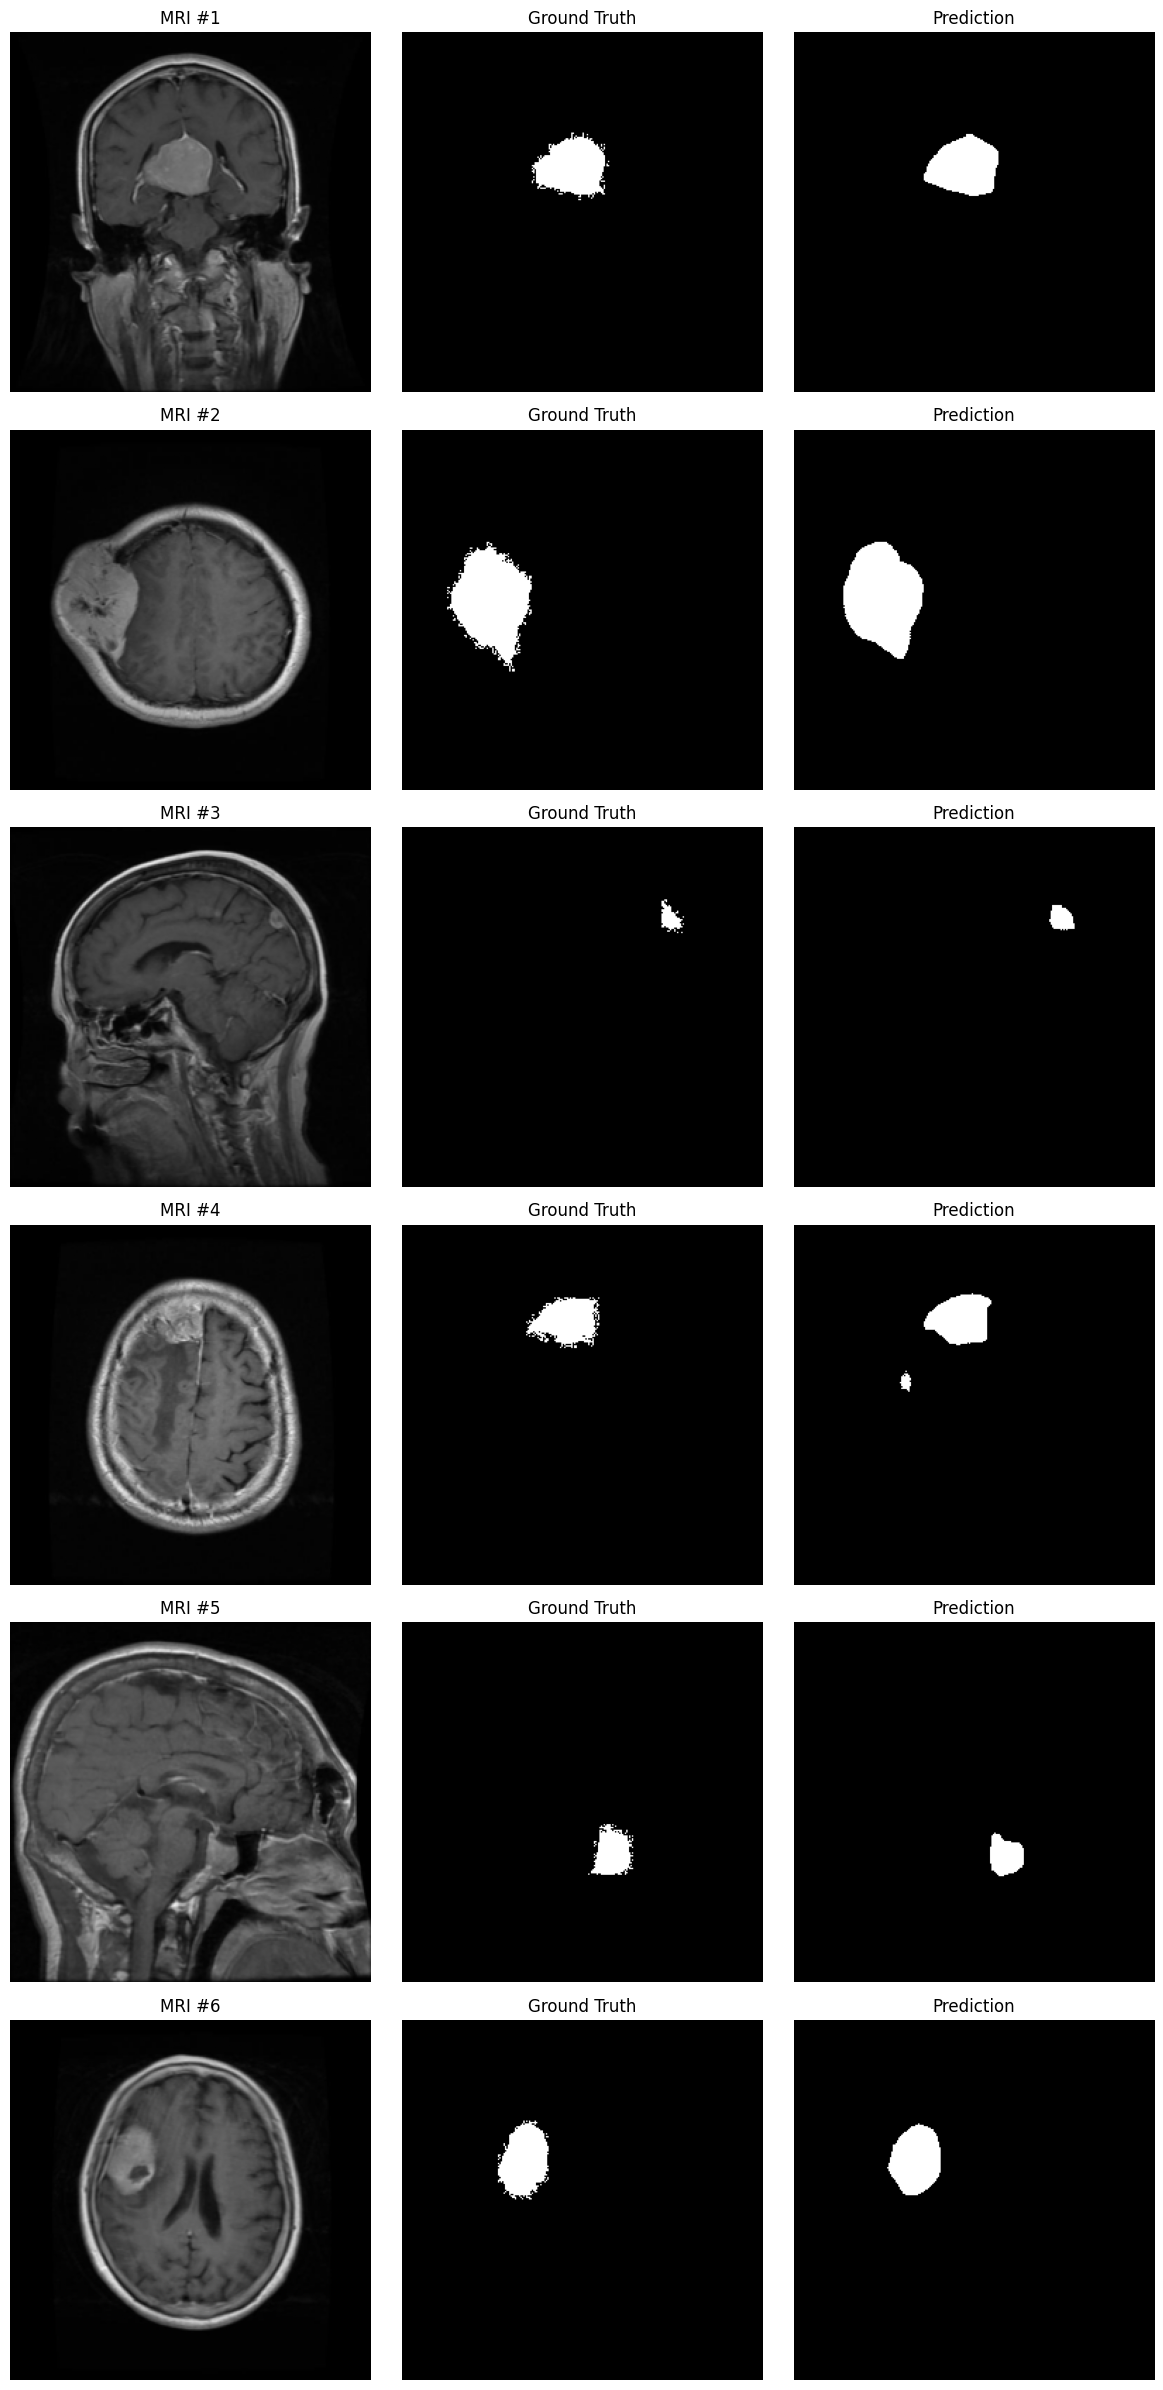

In [20]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_sample(model, loader, threshold=0.5):
    """Visualize one sample: image, ground truth mask, and prediction."""
    model.eval()
    images, labels = next(iter(loader))

    image = images.to(device)
    label = labels.to(device)

    with torch.no_grad():
        output = model(image)
        pred = torch.sigmoid(output) > threshold

    image = image.cpu().numpy()[0].transpose(1, 2, 0)
    label = label.cpu().numpy()[0, 0]
    pred = pred.cpu().numpy()[0, 0]

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.title("MRI")
    plt.imshow(image)
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.title("Ground Truth")
    plt.imshow(label, cmap="gray")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.title("Prediction")
    plt.imshow(pred, cmap="gray")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


def visualize_multiple_samples(model, loader, n_samples=6, threshold=0.5):
    """Visualize multiple samples in a grid with 3 columns per sample.

    Each row = [MRI, Ground Truth, Prediction].
    """
    model.eval()

    collected_images = []
    collected_labels = []
    collected_preds = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = (torch.sigmoid(outputs) > threshold).float()

            for i in range(images.size(0)):
                collected_images.append(images[i].cpu().numpy().transpose(1, 2, 0))
                collected_labels.append(labels[i].cpu().numpy()[0])
                collected_preds.append(preds[i].cpu().numpy()[0])

                if len(collected_images) >= n_samples:
                    break

            if len(collected_images) >= n_samples:
                break

    if len(collected_images) == 0:
        print("Aucun échantillon trouvé dans le loader.")
        return

    n = len(collected_images)
    fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))

    # Ensure axes is 2D when n == 1
    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    for idx in range(n):
        axes[idx, 0].imshow(collected_images[idx])
        axes[idx, 0].set_title(f"MRI #{idx + 1}")
        axes[idx, 0].axis("off")

        axes[idx, 1].imshow(collected_labels[idx], cmap="gray")
        axes[idx, 1].set_title("Ground Truth")
        axes[idx, 1].axis("off")

        axes[idx, 2].imshow(collected_preds[idx], cmap="gray")
        axes[idx, 2].set_title("Prediction")
        axes[idx, 2].axis("off")

    plt.tight_layout()
    plt.show()


# Exemple d'utilisation (uses tuned threshold if available)
auto_threshold = best_threshold if "best_threshold" in globals() else 0.5
visualize_multiple_samples(model, val_loader, n_samples=6, threshold=auto_threshold)